# fetch california housing

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
%matplotlib inline

In [ ]:
# 캘리포니아 주택 가격 예측을 위한 회귀(regression) 데이터셋 로드
# 각 지역의 인구, 소득, 방 개수 등 특징을 활용해 집값(median_house_value)을 예측하는 데 사용됨
data = fetch_california_housing()

In [3]:
print(type(data))

<class 'sklearn.utils._bunch.Bunch'>


In [4]:
print(data.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [5]:
print(type(data))

<class 'sklearn.utils._bunch.Bunch'>


In [6]:
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [8]:
print(data.target_names)

['MedHouseVal']


In [9]:
print(data.feature_names)

['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [10]:
df = pd.DataFrame(data=data.data, columns=data.feature_names)
df['target'] = data.target

In [11]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [13]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [15]:
print(df.isnull().sum())

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64


<Axes: >

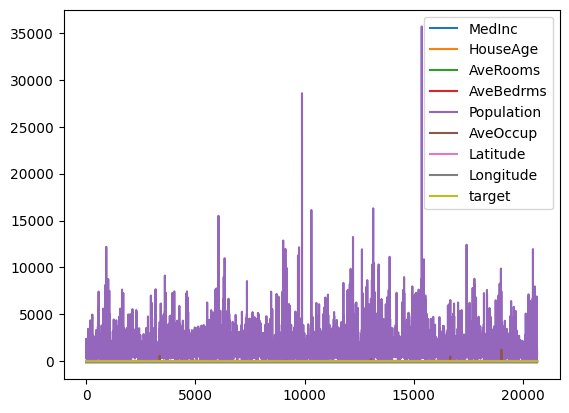

In [16]:
df.plot()

In [17]:
# PyTorch 기본 패키지 (텐서 연산, 자동 미분 등 핵심 기능 제공)
import torch

# 신경망 모델 구성용 모듈 (Linear, Conv 등 레이어 정의)
import torch.nn as nn

# 활성화 함수(ReLU, Softmax 등) 및 신경망 관련 유틸 함수
import torch.nn.functional as F

# 최적화 알고리즘(Adam, SGD 등) 제공
import torch.optim as optim

# Dataset, DataLoader 등 데이터셋 관리 및 배치를 위한 도구
import torch.utils.data as data_utils


In [18]:
# 캘리포니아 주택 가격 예측을 위한 단순 회귀 신경망 모델 정의
class CaliforniaHousingModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(CaliforniaHousingModel, self).__init__()

        # 입력층 → 은닉층(16 노드) → 출력층 구조의 MLP 모델
        # 회귀 문제이므로 마지막에 활성화 함수 없이 선형 출력 사용
        self.model = nn.Sequential(
            nn.Linear(input_size, 16),  # 입력 특징 → 은닉층
            nn.ReLU(),                  # 비선형 활성화 함수
            nn.Linear(16, output_size)  # 은닉층 → 출력층(예측값)
        )
        
    def forward(self, x):
        # 순전파 계산 수행
        output = self.model(x)

        # 회귀 문제이므로 결과값 그대로 반환
        return output

In [19]:
X = torch.Tensor(data.data)
y = torch.Tensor(data.target)

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # train과 test를 8:2로 분할

In [21]:
model = CaliforniaHousingModel(8, 1)

In [22]:
n = 0
y = model(X_train[n]).detach() # 더 이상 연산을 추적하지 않는다
print(y, y_train[n])

tensor([-10.0506]) tensor(0.9330)


In [24]:
# 모델 파라미터를 업데이트하기 위해 Adam optimizer 설정
# lr=0.001 → 학습률(learning rate), 파라미터가 얼마나 빠르게 업데이트될지 결정
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [25]:
print(model)

CaliforniaHousingModel(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [26]:
# 입력 특징 8개, 출력 1개(집값 예측)인 회귀 모델 생성
model = CaliforniaHousingModel(8, 1)

# Adam optimizer 설정 (학습률 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 회귀 문제에서 사용하는 평균제곱오차(MSE) 손실 함수
criterion = nn.MSELoss()

# 학습 반복 횟수 설정
n_epochs = 10000

avg_loss = 0

for epoch in range(n_epochs):

    # 순전파
    y = model(X_train)  # 모델의 예측값
    target = torch.unsqueeze(y_train, dim=1)  # 타깃 모양을 (N,1)으로 변환

    # 손실 계산 (MSELoss → 회귀 문제용)
    loss = criterion(y, target).sum()

    # 역전파 및 파라미터 업데이트
    optimizer.zero_grad()  # 이전 gradient 초기화
    loss.backward()        # gradient 계산
    optimizer.step()       # 모델 파라미터 업데이트

    # 중간 출력
    if epoch % 1000 == 0:
        # 학습 진행 상황 확인
        print('epoch {}th loss: {}'.format(epoch, loss.data))


epoch 0th loss: 51885.3984375
epoch 1000th loss: 1.3054792881011963
epoch 2000th loss: 1.1647791862487793
epoch 3000th loss: 1.0462216138839722
epoch 4000th loss: 0.9263546466827393
epoch 5000th loss: 0.8119618892669678
epoch 6000th loss: 0.732450008392334
epoch 7000th loss: 0.6813115477561951
epoch 8000th loss: 0.6465476751327515
epoch 9000th loss: 0.6235951781272888


In [27]:
n = 99
y = model(X_train[n]).detach() # 더 이상 연산을 추적하지 않는다
print(y, y_train[n])

tensor([3.0637]) tensor(2.7240)


In [ ]:
# 입력 8개(feature), 출력 1개(집값 예측)인 회귀 모델 생성
model = CaliforniaHousingModel(8, 1)

# Adam optimizer 설정 (학습률 0.0005)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# 회귀 문제에 사용되는 MSE 손실 함수
criterion = nn.MSELoss()

# 학습 반복 횟수
n_epochs = 15000

# 학습/테스트 손실 기록용 리스트
list_training_loss = []
list_test_loss = []

for epoch in range(n_epochs):

    # 학습 단계
    model.train()  # 학습 모드 활성화
    y = model(X_train)  # 모델의 예측값
    target = torch.unsqueeze(y_train, dim=1)  # 타깃 모양을 (N,1)으로 변환
    loss = criterion(y, target).sum()  # 학습 손실 계산

    optimizer.zero_grad()  # 기존 gradient 초기화
    loss.backward()        # 역전파(gradient 계산)
    optimizer.step()       # 파라미터 업데이트

    # 평가 단계 (1000 epoch마다 출력)
    if epoch % 1000 == 0:
        model.eval()  # 평가 모드 활성화
        y_pred = model(X_test).squeeze()  # 예측 후 1차원으로 변환
        test_loss = criterion(y_pred, y_test).sum()  # 테스트 손실 계산

        # 학습 및 테스트 손실 출력
        print('epoch {}th training loss: {} test loss: {}'.format(
            epoch, loss.data, test_loss.data))

        # 손실 기록 저장
        list_training_loss.append(loss.data)
        list_test_loss.append(test_loss.data)


epoch 0th training loss: 9572.6083984375 test loss: 7906.6181640625
epoch 1000th training loss: 1.4027681350708008 test loss: 1.342747449874878
epoch 2000th training loss: 0.8332725763320923 test loss: 0.7945418357849121
epoch 3000th training loss: 0.6989023089408875 test loss: 0.6655710935592651
epoch 4000th training loss: 0.646336019039154 test loss: 0.6243555545806885
epoch 5000th training loss: 0.6227725744247437 test loss: 0.6074642539024353
epoch 6000th training loss: 0.6118060946464539 test loss: 0.5997128486633301
epoch 7000th training loss: 0.6042696833610535 test loss: 0.5947422385215759
epoch 8000th training loss: 0.5986436009407043 test loss: 0.584153413772583
epoch 9000th training loss: 0.5917145609855652 test loss: 0.5654644966125488
epoch 10000th training loss: 0.5887323617935181 test loss: 0.5613463521003723
epoch 11000th training loss: 0.627801239490509 test loss: 0.5837089419364929
epoch 12000th training loss: 0.5883526802062988 test loss: 0.5598704814910889
epoch 130

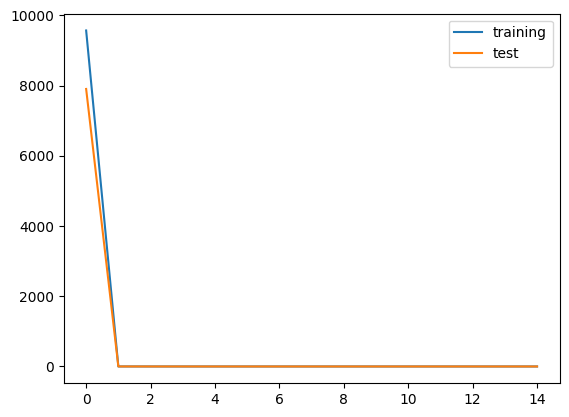

In [29]:
import matplotlib.pyplot as plt

plt.plot(list_training_loss, label='training')
plt.plot(list_test_loss, label='test')
plt.legend()
plt.show()

In [33]:
from sklearn.metrics import r2_score

# 추론 모드에서는 gradient 계산 비활성화
with torch.no_grad():

    # 테스트 데이터에 대한 모델 예측 수행
    y_pred = model(X_test)

    # R²(결정계수) 계산
    # → 모델이 실제 값(y_test)의 변동성을 얼마나 설명하는지 평가하는 회귀 성능 지표
    score = r2_score(y_test, y_pred)

    # R² 점수 출력 (1에 가까울수록 예측력이 높음)
    print(score)


0.5633889436721802


In [34]:
# MAPE(Mean Absolute Percentage Error) 손실 함수 정의
# → 실제값 대비 예측값의 오차 비율을 계산하는 회귀 평가 지표
class MAPELoss(nn.Module):
    def __init__(self):
        super(MAPELoss, self).__init__()

    def forward(self, y_pred, y_true):
        epsilon = 1e-8  # 0으로 나누는 것을 방지하기 위한 작은 값
        # |(실제값 - 예측값) / 실제값| 의 평균을 계산
        loss = torch.mean(torch.abs((y_true - y_pred) / (y_true + epsilon)))
        return loss * 100  # 백분율(%) 표현을 위해 100 곱함

# MAPE 손실 함수 객체 생성
mape_loss = MAPELoss()

# 테스트 데이터 예측값 계산 (1차원으로 변환)
y_pred = model(X_test).squeeze()

# MAPE 손실 계산
loss_value = mape_loss(y_pred, y_test)

# 결과 출력
print(f"MAPE Loss: {loss_value.item():.4f}%")


MAPE Loss: 33.7059%


In [40]:
# 입력 8개(feature), 출력 1개(집값 예측)인 회귀 모델 생성
model = CaliforniaHousingModel(8, 1)

# Adam optimizer 설정 (학습률 0.0005)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# 회귀 문제용 MAPE(%) 기반 손실 함수 사용
criterion = MAPELoss()

# 학습 반복 횟수
n_epochs = 10000

# 학습/테스트 손실 기록 리스트
list_training_loss = []
list_test_loss = []

for epoch in range(n_epochs):

    # 학습 단계
    model.train()                     # 학습 모드 활성화
    y = model(X_train)                # 모델 예측값
    target = torch.unsqueeze(y_train, dim=1)  # 타깃 모양을 (N,1)으로 정렬
    loss = criterion(y, target)       # MAPE 손실 계산

    optimizer.zero_grad()             # 기존 gradient 초기화
    loss.backward()                   # 역전파 수행
    optimizer.step()                  # 파라미터 업데이트

    # 평가 단계 (1000 epoch마다)
    if epoch % 1000 == 0:
        model.eval()                  # 평가 모드 활성화
        y_pred = model(X_test).squeeze()   # 테스트 예측 (1차원 형태로 변환)
        test_loss = criterion(y_pred, y_test)  # 테스트 MAPE 계산

        # 학습/테스트 손실 출력
        print('epoch {}th training loss: {} test loss: {}'.format(
            epoch, loss.data, test_loss.data
        ))

        # 손실 기록 저장
        list_training_loss.append(loss.data)
        list_test_loss.append(test_loss.data)


epoch 0th training loss: 19974.333984375 test loss: 19051.63671875
epoch 1000th training loss: 41.59064483642578 test loss: 41.596031188964844
epoch 2000th training loss: 31.327280044555664 test loss: 31.35702896118164
epoch 3000th training loss: 29.859437942504883 test loss: 29.867300033569336
epoch 4000th training loss: 29.054880142211914 test loss: 29.006839752197266
epoch 5000th training loss: 28.525279998779297 test loss: 28.487564086914062
epoch 6000th training loss: 28.272607803344727 test loss: 28.30486297607422
epoch 7000th training loss: 27.907947540283203 test loss: 27.892580032348633
epoch 8000th training loss: 27.946237564086914 test loss: 27.837265014648438
epoch 9000th training loss: 27.920909881591797 test loss: 27.916141510009766


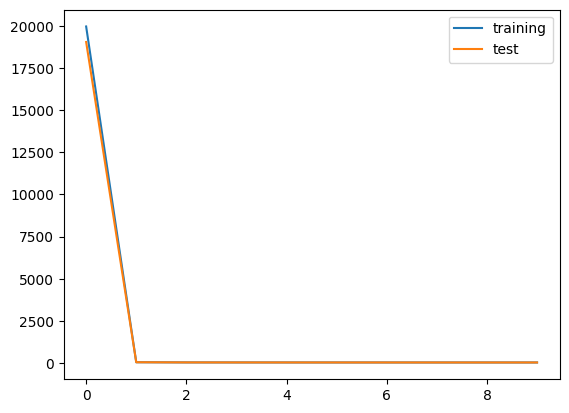

In [41]:
import matplotlib.pyplot as plt

plt.plot(list_training_loss, label='training')
plt.plot(list_test_loss, label='test')
plt.legend()
plt.show()

In [42]:
from sklearn.metrics import r2_score

# 추론 단계에서는 gradient 계산을 비활성화
with torch.no_grad():

    # 테스트 데이터에 대한 모델 예측 수행
    y_pred = model(X_test)

    # R²(결정계수) 계산
    # → 모델이 실제 값(y_test)의 변동성을 얼마나 설명하는지 나타내는 지표
    #   1에 가까울수록 예측 성능이 높고, 0 이하면 모델이 평균보다 못한 성능을 의미
    score = r2_score(y_test, y_pred)

    # R² 점수 출력
    print(score)


0.43091922998428345


In [43]:
# MAPE(평균 절대 백분율 오차) 손실 함수 객체 생성
mape_loss = MAPELoss()

# 테스트 데이터에 대한 모델 예측 수행 (결과를 1차원으로 변환)
y_pred = model(X_test).squeeze()

# 예측값(y_pred)과 실제값(y_test) 사이의 MAPE 계산
loss_value = mape_loss(y_pred, y_test)

# MAPE 손실 값을 퍼센트(%) 형식으로 출력
print(f"MAPE Loss: {loss_value.item():.4f}%")


MAPE Loss: 27.8604%
